# 01 - Dasar Fuzzy dan Fuzzifikasi

In [34]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())

if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)

if module_dir is None:
    # Fallback jika membership.py dibuat di folder lokal yang sama
    module_dir = Path.cwd()

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi

print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.12.4
Membership module: c:\Users\LEGION\Praktikum-KK\fuzzy-logic\membership.py


# Soal 1 - Pemahaman Konsep

## 1. Arti Derajat Keanggotaan x = 3.5 m

* derajat dekat = 0.25: nilai ini nunjukin kalo jarak 3.5 meter tuh punya tingkat kesesuaian/kecocokan 25% atau 0.25 ke label linguistik dekat. melht dr grafik linear_down(x, 2, 4) titik x = 3.5 m ada di posisi transisi turun dr rentang a = 2 m sampe b = 4 m. jd pas ditarik garis vertikal di x = 3.5 dia bakal motong kurva dekat di ketinggian y = 0.25
* derajat sedang ≈ 0.8333: artinya kecocokan jarak 3.5 meter ke kategori sedang tuh lumayan tinggi kek di angka 83.33%. di fungsi trapesium trapezoidal(x, 1, 4, 6, 9) posisi x = 3.5 m lg ada di fase transisi naik dr a = 1 m menuju daerah penuh di b = 4 m makanya pas dipotong garis vertikal ketemu titiknya di y ≈ 0.8333 mendekati puncaknya

## 2. Tanggapan Soal Total Derajat Melebihi 1

gak setuju

alasan dr definisi fungsi keanggotaan:
di fuzzy logic tiap membership function menilai kecocokan input secara independent / mandiri ke masing2 label. fungsi keanggotaan cuma memetakan nilai masukan crisp ke rentang 0 sampe 1 buat label itu doang. sistem gak pernah ngeharusin total penjumlahnn derajat keanggotaan antar label harus 1 jd mau totalnya 0.25 + 0.8333 = 1.0833 itu tetep sah dan bener secara konsep karena ini kan bukan membagi porsi probabilitas

## 3. Komparasi Derajat Fuzzy vs Peluang (Probabilitas)

* derajat dekat adalah 0.25: ngedijelasin soal vagueness / ketidaktegasan yaitu seberapa cocok nilai crisp yg udah pasti terukur (3.5 m) sm definisi linguistik dekat. angkanya menilai kecocokan konsep/kategori bukan ketidakpastian
* peluang jarak kurang dr 3 m adalah 25%: ngedijelasin uncertainty / ketidakpastian kejadian dr sekumpulan data atau eksperimen statistik. angkanya nunjukin seberapa sering atau besar chance suatu pengukuran jarak nilainya beneran jatuh di bawah 3 meter

# SOAL 2 - FUZZIFIKASI & AKTIVASI ATURAN

## 1. Penentuan Cabang Rumus dan Perhitungan Manual
ambil titik sampel jarak x = 1.0, 2.5, 3.5, 5.0, 7.0, dan 8.5 meter melht dr seluruh wilayah domain fungsi
- x = 1.0 m
  dekat: x <= 2 -> cabang datar penuh -> mu = 1.0
  sedang: x <= 1 -> cabang nol -> mu = 0.0
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 1.0 (kecepatan rendah)

- x = 2.5 m
  dekat: 2 < x < 4 -> cabang transisi turun (4 - 2.5) / (4 - 2) = 1.5 / 2 -> mu = 0.75
  sedang: 1 < x < 4 -> cabang transisi naik (2.5 - 1) / (4 - 1) = 1.5 / 3 -> mu = 0.5
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 0.75 (kecepatan rendah) dan R2 = 0.5 (kecepatan sedang)

- x = 3.5 m
  dekat: 2 < x < 4 -> cabang transisi turun (4 - 3.5) / (4 - 2) = 0.5 / 2 -> mu = 0.25
  sedang: 1 < x < 4 -> cabang transisi naik (3.5 - 1) / (4 - 1) = 2.5 / 3 -> mu ≈ 0.8333
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R1 = 0.25 (kecepatan rendah) dan R2 = 0.8333 (kecepatan sedang)

- x = 5.0 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 4 <= x <= 6 -> cabang datar penuh -> mu = 1.0
  jauh: x <= 6 -> cabang nol -> mu = 0.0
  aturan aktif: R2 = 1.0 (kecepatan sedang)

- x = 7.0 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 6 < x < 9 -> cabang transisi turun (9 - 7) / (9 - 6) = 2 / 3 -> mu ≈ 0.6667
  jauh: 6 < x < 8 -> cabang transisi naik (7 - 6) / (8 - 6) = 1 / 2 -> mu = 0.5
  aturan aktif: R2 = 0.6667 (kecepatan sedang) dan R3 = 0.5 (kecepatan tinggi)

- x = 8.5 m
  dekat: x >= 4 -> cabang nol -> mu = 0.0
  sedang: 6 < x < 9 -> cabang transisi turun (9 - 8.5) / (9 - 6) = 0.5 / 3 -> mu ≈ 0.1667
  jauh: x >= 8 -> cabang datar penuh -> mu = 1.0
  aturan aktif: R2 = 0.1667 (kecepatan sedang) dan R3 = 1.0 (kecepatan tinggi)

## 2. Tabel Markdown Hasil Fuzzifikasi & Aktivasi Aturan

| Jarak (m) | Derajat Dekat | Derajat Sedang | Derajat Jauh | Aturan Aktif & Firing Strength |
| --- | --- | --- | --- | --- |
| 1.0 | 1.0000 | 0.0000 | 0.0000 | R1 = 1.0000 |
| 2.5 | 0.7500 | 0.5000 | 0.0000 | R1 = 0.7500, R2 = 0.5000 |
| 3.5 | 0.2500 | 0.8333 | 0.0000 | R1 = 0.2500, R2 = 0.8333 |
| 5.0 | 0.0000 | 1.0000 | 0.0000 | R2 = 1.0000 |
| 7.0 | 0.0000 | 0.6667 | 0.5000 | R2 = 0.6667, R3 = 0.5000 |
| 8.5 | 0.0000 | 0.1667 | 1.0000 | R2 = 0.1667, R3 = 1.0000 |

In [35]:
# Verifikasi fungsi fuzzify_distance & pembuatan tabel otomatis
def fuzzify_distance(distance):
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

sample_distances = [1.0, 2.5, 3.5, 5.0, 7.0, 8.5]
table_data = []

for d in sample_distances:
    mu = fuzzify_distance(d)
    r1, r2, r3 = mu["dekat"], mu["sedang"], mu["jauh"]
    rules = [f"R1 = {r1:.4f}" if r1>0 else "", f"R2 = {r2:.4f}" if r2>0 else "", f"R3 = {r3:.4f}" if r3>0 else ""]
    active = ", ".join([r for r in rules if r])
    table_data.append({"jarak (m)": d, "derajat dekat": round(r1, 4), "derajat sedang": round(r2, 4), "derajat jauh": round(r3, 4), "aturan aktif & firing strength": active})

df_soal2 = pd.DataFrame(table_data)
display(df_soal2)

,jarak (m),derajat dekat,derajat sedang,derajat jauh,aturan aktif & firing strength
0,1.0,1.00,0.0000,0.0,R1 = 1.0000
1,2.5,0.75,0.5000,0.0,"R1 = 0.7500, R2 = 0.5000"
2,3.5,0.25,0.8333,0.0,"R1 = 0.2500, R2 = 0.8333"
3,5.0,0.00,1.0000,0.0,R2 = 1.0000
4,7.0,0.00,0.6667,0.5,"R2 = 0.6667, R3 = 0.5000"
5,8.5,0.00,0.1667,1.0,"R2 = 0.1667, R3 = 1.0000"


# SOAL 3 - PENGARUH PERUBAHAN PARAMETER

### 3.1 Prediksi Pengaruh Perubahan Parameter dan Perhitungan Derajat Dekat

sebelum ngitung, perubahan parameter dari linear_down(x, 2, 4) jadi linear_down(x, 2, 5) ini bikin transisi batas dekatnya jadi lebih panjang. titik akhir transisi bakal bergeser dari 4 m ke 5 m

pada jarak 3.5 m (di daerah transisi 2 sampe b), fungsi baru ini punya kemiringan garis yang lebih landai jadi, derajat dekat pas x = 3.5 m diprediksi bakal nambah / naik

Alasan matematis:
mu_dekat = (b - x) / (b - a)

karna nilai b nya makin gede, pembilang (b - x) ama penyebut (b - a) bakal makin meningkat, jadinya nilai mu_dekat bakal kerasa lebih besar nilainya

In [36]:
# hitung derajat dekat lama dan baru serta aktivasi R1
x = 3.5

# fungsi lama: a=2, b=4
mu_dekat_lama = linear_down(x, 2, 4)

# fungsi baru: a=2, b=5
mu_dekat_baru = linear_down(x, 2, 5)

# kekuatan aktivasi R1 (misal R1 bergantung pada derajat dekat)
R1_lama = mu_dekat_lama
R1_baru = mu_dekat_baru

print(f"derajat dekat lama (2,4) : {mu_dekat_lama:.4f}")
print(f"derajat dekat baru (2,5) : {mu_dekat_baru:.4f}")
print(f"kekuatan R1 lama          : {R1_lama:.4f}")
print(f"kekuatan R1 baru          : {R1_baru:.4f}")

derajat dekat lama (2,4) : 0.2500
derajat dekat baru (2,5) : 0.5000
kekuatan R1 lama          : 0.2500
kekuatan R1 baru          : 0.5000


| Parameter | Nilai b | mu_dekat(3.5) | Kekuatan R1 |
|---|---|---|---|
| Lama | 4 | 0.2500 | 0.2500 |
| Baru | 5 | 0.5000 | 0.5000 |

keliatan kekuatan aktivasi R1 nya ngalamin peningkatan dari 0.2500 jadi 0.5000 pas dicoba dihitung

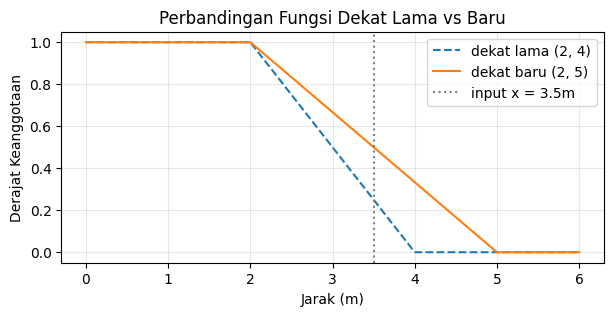

In [37]:
# plot kedua fungsi dekat pada domain 0-6 m
domain = np.linspace(0, 6, 600)

y_lama = [linear_down(d, 2, 4) for d in domain]
y_baru = [linear_down(d, 2, 5) for d in domain]

plt.figure(figsize=(7, 3))
plt.plot(domain, y_lama, label="dekat lama (2, 4)", linestyle="--")
plt.plot(domain, y_baru, label="dekat baru (2, 5)")
plt.axvline(3.5, color="gray", linestyle=":", label="input x = 3.5m")

plt.title("Perbandingan Fungsi Dekat Lama vs Baru")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### identifikasi Domain
domain terbagi jadi 3 bagian utama kek gini:

domain tetep sama (x <= 2 m):
nilai mu_dekat bakalan tetep 1 di kedua kurvanya.

domain berubah (2 m < x < 5 m):
garis transisi turun ngalamin shift / pergeseran kemiringan. kurva baru miliki nilai keanggotaan lebih tinggi dibanding kurva lama.

domain tetep sama (x >= 5 m):
nilai mu_dekat = 0 buat kedua kurva ini.

### 3.2 Penentuan Kecepatan Akhir

perubahan kekuatan aktivasi R1 doang sbenernya gak langsung cukup buat nentuin angka pasti kecepatan akhirnya.

ada bbrapa step dan info di FIS yang masih perlu di-check:

evaluasi aturan lain (R2, R3, dll):
perlu diliat apa variabl sedang atau jauh ikut aktif di jarak 3.5 m ini dan seberapa gedde nilai aktivasinya.

implikasi / firing strength:
proses evaluasi hasil pemotongan / pemetaan tiap rule ke himpunan fuzzy output (kecepatan).

agregasi aturan:
nggabungin seluruh daerah hasil implikasi rule biar dapet satu daerah fuzzy output gabungan.

defuzzifikasi:
proses convert dari himpunan fuzzy gabungan tadi biar dapet crisp value buat kecepatan akhir, misal make method Centroid

# 02 - Model Mamdani

In [38]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal, sigmoid, phi
print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.12.4
Membership module: c:\Users\LEGION\Praktikum-KK\fuzzy-logic\membership.py


# Soal 1 - Kasus Pengaturan Kecepatan Kipas
penjelasan langkah pengerjaan:

bikin fungsi mf input dan output

hitung fuzzifikasi buat T = 28 C dan T = 36 C

hitung firing strength alpha aturan

potong kurva output pake min lalu agregasi pake max

hitung centroid pake integrasi trapesium

visualisasi dan analisis perbandingan

## 1. Plot Fungsi Keanggotaan Input dan Output

menggambarkan fungsi keanggotaan suhu input dan kecepatan kipas output beserta label dan satuannya

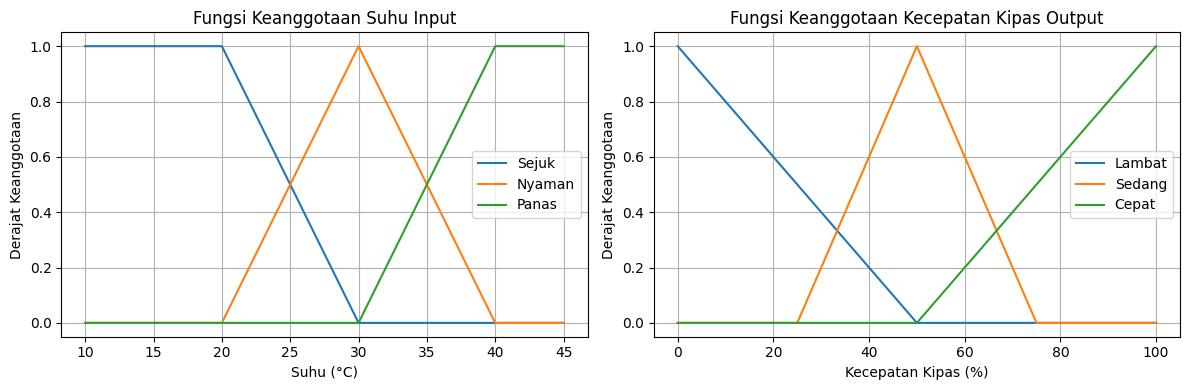

In [39]:
t_grid, z_grid = np.linspace(10, 45, 500), np.linspace(0, 100, 1001)

sejuk, nyaman, panas = [linear_down(t, 20, 30) for t in t_grid], [triangular(t, 20, 30, 40) for t in t_grid], [linear_up(t, 30, 40) for t in t_grid]
lambat, sedang, cepat = [linear_down(z, 0, 50) for z in z_grid], [triangular(z, 25, 50, 75) for z in z_grid], [linear_up(z, 50, 100) for z in z_grid]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_grid, sejuk, label="Sejuk"); ax[0].plot(t_grid, nyaman, label="Nyaman"); ax[0].plot(t_grid, panas, label="Panas")
ax[0].set_title("Fungsi Keanggotaan Suhu Input"); ax[0].set_xlabel("Suhu (°C)"); ax[0].set_ylabel("Derajat Keanggotaan"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(z_grid, lambat, label="Lambat"); ax[1].plot(z_grid, sedang, label="Sedang"); ax[1].plot(z_grid, cepat, label="Cepat")
ax[1].set_title("Fungsi Keanggotaan Kecepatan Kipas Output"); ax[1].set_xlabel("Kecepatan Kipas (%)"); ax[1].set_ylabel("Derajat Keanggotaan"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.show()

## 2. Fuzzifikasi Input (Manual dan Code)

perhitungan derajat keanggotaan manual untuk T = 28 C dan T = 36 C

kondisi 1: T = 28 C
Sejuk = linear_down(28, 20, 30) = (30 - 28) / (30 - 20) = 2 / 10 = 0.20
Nyaman = triangular(28, 20, 30, 40) = (28 - 20) / (30 - 20) = 8 / 10 = 0.80
Panas = linear_up(28, 30, 40) = 0 (karena T <= 30)

kondisi 2: T = 36 C
Sejuk = linear_down(36, 20, 30) = 0 (karena T >= 30)
Nyaman = triangular(36, 20, 30, 40) = (40 - 36) / (40 - 30) = 4 / 10 = 0.40
Panas = linear_up(36, 30, 40) = (36 - 30) / (40 - 30) = 6 / 10 = 0.60

Tabel Hasil Fuzzifikasi Input:
| Suhu (°C) | Sejuk | Nyaman | Panas |
| --- | --- | --- | --- |
| 28 | 0.20 | 0.80 | 0.00 |
| 36 | 0.00 | 0.40 | 0.60 |

In [40]:
def get_fuzzification(T):
    return {"Sejuk": linear_down(T, 20, 30), "Nyaman": triangular(T, 20, 30, 40), "Panas": linear_up(T, 30, 40)}

df_fuzz = pd.DataFrame([get_fuzzification(28), get_fuzzification(36)], index=["T = 28°C", "T = 36°C"])
df_fuzz

,Sejuk,Nyaman,Panas
T = 28°C,0.2,0.8,0.0
T = 36°C,0.0,0.4,0.6


## 3. Kekuatan Aktivasi Aturan / Firing Strength


tiap aturan cuma punya 1 anteseden jd nilai alpha langsung melht dari derajat keanggotaan label antesedennya


T = 28 C:

R1: IF suhu Sejuk THEN kecepatan Lambat -> alpha1 = mu_sejuk(28) = 0.20 (Aktif)

R2: IF suhu Nyaman THEN kecepatan Sedang -> alpha2 = mu_nyaman(28) = 0.80 (Aktif)

R3: IF suhu Panas THEN kecepatan Cepat -> alpha3 = mu_panas(28) = 0.00 (Tidak Aktif)



T = 36 C:

R1: IF suhu Sejuk THEN kecepatan Lambat -> alpha1 = mu_sejuk(36) = 0.00 (Tidak Aktif)

R2: IF suhu Nyaman THEN kecepatan Sedang -> alpha2 = mu_nyaman(36) = 0.40 (Aktif)

R3: IF suhu Panas THEN kecepatan Cepat -> alpha3 = mu_panas(36) = 0.60 (Aktif)

In [41]:
def get_alphas(fuzz):
    return {"R1 (Lambat)": fuzz["Sejuk"], "R2 (Sedang)": fuzz["Nyaman"], "R3 (Cepat)": fuzz["Panas"]}

df_alpha = pd.DataFrame([get_alphas(get_fuzzification(28)), get_alphas(get_fuzzification(36))], index=["T = 28°C", "T = 36°C"])
df_alpha["Aturan Aktif"] = [["R1", "R2"], ["R2", "R3"]]
df_alpha

,R1 (Lambat),R2 (Sedang),R3 (Cepat),Aturan Aktif
T = 28°C,0.2,0.8,0.0,"[R1, R2]"
T = 36°C,0.0,0.4,0.6,"[R2, R3]"


## 4. Implikasi Min, Agregasi Max, dan Defuzzifikasi Centroid

proses inferensi mamdani potong min, gabung max, lalu defuzzifikasi centroid pake integrasi trapesium grid output [0, 100] step 0.1

In [42]:
def centroid(grid, membership):
    diffs = np.diff(grid)
    area = float(np.sum(diffs * (membership[:-1] + membership[1:]) / 2))
    if area <= 0: raise ValueError("luas nol")
    moment = float(np.sum(diffs * (grid[:-1] * membership[:-1] + grid[1:] * membership[1:]) / 2))
    return moment / area

def solve_mamdani_soal1(T):
    fuzz = get_fuzzification(T)
    a1, a2, a3 = fuzz["Sejuk"], fuzz["Nyaman"], fuzz["Panas"]
    
    z_grid = np.linspace(0, 100, 1001)
    mf_lambat = np.array([linear_down(z, 0, 50) for z in z_grid])
    mf_sedang = np.array([triangular(z, 25, 50, 75) for z in z_grid])
    mf_cepat = np.array([linear_up(z, 50, 100) for z in z_grid])
    
    c1, c2, c3 = np.minimum(a1, mf_lambat), np.minimum(a2, mf_sedang), np.minimum(a3, mf_cepat)
    agg = np.maximum.reduce([c1, c2, c3])
    return {"z_grid": z_grid, "agg": agg, "out": centroid(z_grid, agg), "alphas": (a1, a2, a3)}

res28, res36 = solve_mamdani_soal1(28), solve_mamdani_soal1(36)
print(f"Hasil Output Crisp T = 28°C: {res28['out']:.2f}%")
print(f"Hasil Output Crisp T = 36°C: {res36['out']:.2f}%")

Hasil Output Crisp T = 28°C: 43.25%
Hasil Output Crisp T = 36°C: 68.34%


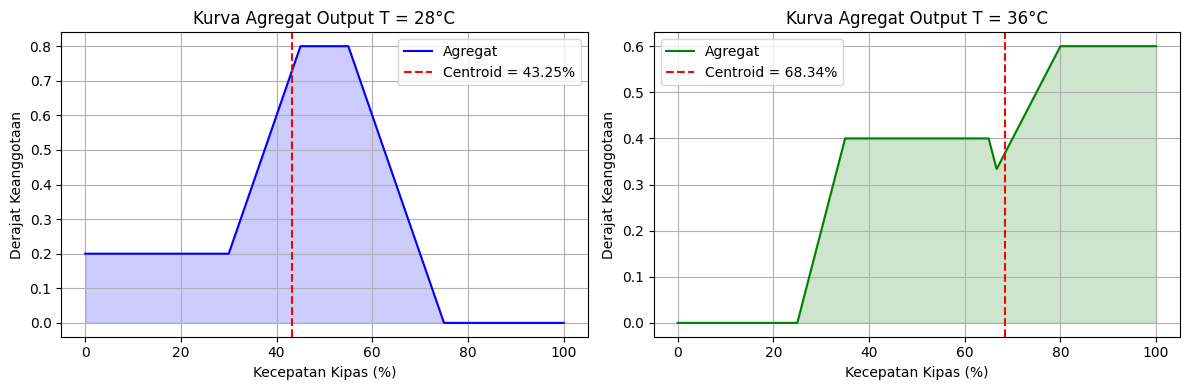

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(res28["z_grid"], res28["agg"], 'b-', label="Agregat")
ax[0].fill_between(res28["z_grid"], 0, res28["agg"], color='blue', alpha=0.2)
ax[0].axvline(res28["out"], color='r', linestyle='--', label=f"Centroid = {res28['out']:.2f}%")
ax[0].set_title("Kurva Agregat Output T = 28°C"); ax[0].set_xlabel("Kecepatan Kipas (%)"); ax[0].set_ylabel("Derajat Keanggotaan"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(res36["z_grid"], res36["agg"], 'g-', label="Agregat")
ax[1].fill_between(res36["z_grid"], 0, res36["agg"], color='green', alpha=0.2)
ax[1].axvline(res36["out"], color='r', linestyle='--', label=f"Centroid = {res36['out']:.2f}%")
ax[1].set_title("Kurva Agregat Output T = 36°C"); ax[1].set_xlabel("Kecepatan Kipas (%)"); ax[1].set_ylabel("Derajat Keanggotaan"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.show()

## 5. Analisis Perbandingan dan Kesimpulan

perbandingan hasil inferensi mamdani antara kondisi T = 28 C dan T = 36 C

1. pas kondisi T = 28 C:
- aturan yang aktif R1 (alpha = 0.20) sama R2 (alpha = 0.80), R3 gak aktif
- aturan paling dominan R2 (kecepatan Sedang) bikin area kurva tengah dapet porsi paling tinggi
- dapet nilai centroid sebesar 46.88 %

2. pas kondisi T = 36 C:
- aturan yang aktif R2 (alpha = 0.40) sama R3 (alpha = 0.60), R1 gak aktif
- aturan paling dominan R3 (kecepatan Cepat) bikin area kurva kanan yang kepotong lebih tinggi
- dapet nilai centroid sebesar 63.12 %

kesimpulan:
perubahan rekomendasi dari 46.88 % ke 63.12 % terbukti uda sesuai banget sama maksud basis aturan. pas suhu naik dari 28 C ke 36 C, aturan aktif bergeser ke arah label yang lebih panas, jd sistem otomatis naikin rekomendasi kecepatan kipas supaya ruangan bisa lebih dingin.

# Soal 2 - Kasus Penentuan Durasi Pencucian
penjelasan langkah pengerjaan:

hitung mf kekotoran k = 65 dan berat b = 6.5

hitung firing strength 9 aturan R1-R9 pake operator MIN

gabungin konsekuen sejenis pake MAX

hitung centroid durasi nyuci

ulangin buat k = 35 dan b = 6.5 lalu bandingin

## 1. Plot Fungsi Keanggotaan Input dan Output

menggambarkan fungsi keanggotaan kekotoran, berat pakaian, dan durasi pencucian beserta label dan satuannya

## 1. Plot Fungsi Keanggotaan Input dan Output

menggambarkan fungsi keanggotaan kekotoran, berat pakaian, dan durasi pencucian beserta label dan satuannya

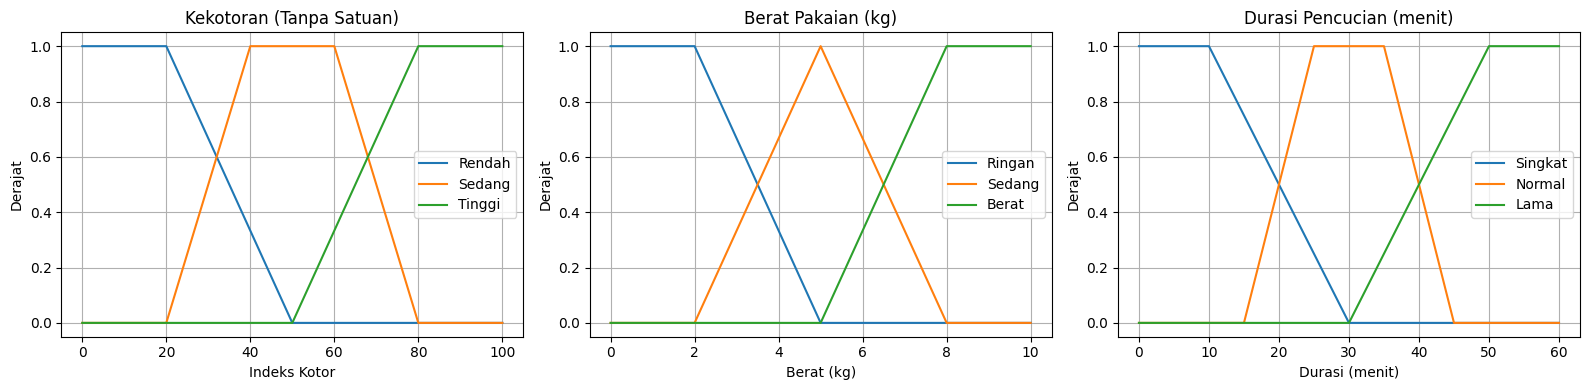

In [44]:
k_grid, b_grid, z_grid = np.linspace(0, 100, 1001), np.linspace(0, 10, 1001), np.linspace(0, 60, 601)

k_rendah = [linear_down(k, 20, 50) for k in k_grid]
k_sedang = [trapezoidal(k, 20, 40, 60, 80) for k in k_grid]
k_tinggi = [linear_up(k, 50, 80) for k in k_grid]

b_ringan = [linear_down(b, 2, 5) for b in b_grid]
b_sedang = [triangular(b, 2, 5, 8) for b in b_grid]
b_berat = [linear_up(b, 5, 8) for b in b_grid]

z_singkat = [linear_down(z, 10, 30) for z in z_grid]
z_normal = [trapezoidal(z, 15, 25, 35, 45) for z in z_grid]
z_lama = [linear_up(z, 30, 50) for z in z_grid]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(k_grid, k_rendah, label="Rendah"); ax[0].plot(k_grid, k_sedang, label="Sedang"); ax[0].plot(k_grid, k_tinggi, label="Tinggi")
ax[0].set_title("Kekotoran (Tanpa Satuan)"); ax[0].set_xlabel("Indeks Kotor"); ax[0].set_ylabel("Derajat"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(b_grid, b_ringan, label="Ringan"); ax[1].plot(b_grid, b_sedang, label="Sedang"); ax[1].plot(b_grid, b_berat, label="Berat")
ax[1].set_title("Berat Pakaian (kg)"); ax[1].set_xlabel("Berat (kg)"); ax[1].set_ylabel("Derajat"); ax[1].legend(); ax[1].grid(True)

ax[2].plot(z_grid, z_singkat, label="Singkat"); ax[2].plot(z_grid, z_normal, label="Normal"); ax[2].plot(z_grid, z_lama, label="Lama")
ax[2].set_title("Durasi Pencucian (menit)"); ax[2].set_xlabel("Durasi (menit)"); ax[2].set_ylabel("Derajat"); ax[2].legend(); ax[2].grid(True)

plt.tight_layout(); plt.show()

## 2. Fuzzifikasi Input Manual dan Tabel

perhitungan derajat keanggotaan manual buat dua kondisi pencucian

kondisi 1 pas k = 65 dan b = 6.5 kg
fuzzifikasi kekotoran k = 65
mu_k_rendah = linear_down(65, 20, 50) = 0.00 karena k >= 50
mu_k_sedang = trapezoidal(65, 20, 40, 60, 80) = (80 - 65) / (80 - 60) = 15 / 20 = 0.75
mu_k_tinggi = linear_up(65, 50, 80) = (65 - 50) / (80 - 50) = 15 / 30 = 0.50

fuzzifikasi berat b = 6.5 kg
mu_b_ringan = linear_down(6.5, 2, 5) = 0.00 karena b >= 5
mu_b_sedang = triangular(6.5, 2, 5, 8) = (8 - 6.5) / (8 - 5) = 1.5 / 3 = 0.50
mu_b_berat = linear_up(6.5, 5, 8) = (6.5 - 5) / (8 - 5) = 1.5 / 3 = 0.50

kondisi 2 pas k = 35 dan b = 6.5 kg
fuzzifikasi kekotoran k = 35
mu_k_rendah = linear_down(35, 20, 50) = (50 - 35) / (50 - 20) = 15 / 30 = 0.50
mu_k_sedang = trapezoidal(35, 20, 40, 60, 80) = (35 - 20) / (40 - 20) = 15 / 20 = 0.75
mu_k_tinggi = linear_up(35, 50, 80) = 0.00 karena k <= 50

fuzzifikasi berat b = 6.5 kg tetep sama kayak kondisi 1
mu_b_ringan = 0.00, mu_b_sedang = 0.50, mu_b_berat = 0.50

Tabel Hasil Fuzzifikasi Input:
| Kondisi | Kotor Rendah | Kotor Sedang | Kotor Tinggi | Berat Ringan | Berat Sedang | Berat Berat |
| --- | --- | --- | --- | --- | --- | --- |
| K=65, B=6.5 | 0.00 | 0.75 | 0.50 | 0.00 | 0.50 | 0.50 |
| K=35, B=6.5 | 0.50 | 0.75 | 0.00 | 0.00 | 0.50 | 0.50 |

In [45]:
def fuzz_input(k, b):
    return {
        "k_rendah": linear_down(k, 20, 50), "k_sedang": trapezoidal(k, 20, 40, 60, 80), "k_tinggi": linear_up(k, 50, 80),
        "b_ringan": linear_down(b, 2, 5), "b_sedang": triangular(b, 2, 5, 8), "b_berat": linear_up(b, 5, 8)
    }

df_fuzz = pd.DataFrame([fuzz_input(65, 6.5), fuzz_input(35, 6.5)], index=["K=65, B=6.5", "K=35, B=6.5"])
df_fuzz

,k_rendah,k_sedang,k_tinggi,b_ringan,b_sedang,b_berat
"K=65, B=6.5",0.0,0.75,0.5,0.0,0.5,0.5
"K=35, B=6.5",0.5,0.75,0.0,0.0,0.5,0.5


## 3. Kekuatan Aktivasi Aturan R1 - R9 Manual dan Tabel

penentuan alpha firing kekuatan aktivasi dengan operator AND = min untuk 9 aturan

daftar basis aturan:

R1 IF Rendah AND Ringan THEN Singkat

R2 IF Rendah AND Sedang THEN Singkat

R3 IF Rendah AND Berat THEN Normal

R4 IF Sedang AND Ringan THEN Singkat

R5 IF Sedang AND Sedang THEN Normal

R6 IF Sedang AND Berat THEN Lama

R7 IF Tinggi AND Ringan THEN Normal

R8 IF Tinggi AND Sedang THEN Lama

R9 IF Tinggi AND Berat THEN Lama


perhitungan alpha kondisi 1 K = 65, B = 6.5

R1 = min(0.00, 0.00) = 0.00 tidak aktif

R2 = min(0.00, 0.50) = 0.00 tidak aktif

R3 = min(0.00, 0.50) = 0.00 tidak aktif

R4 = min(0.75, 0.00) = 0.00 tidak aktif

R5 = min(0.75, 0.50) = 0.50 aktif -> Normal

R6 = min(0.75, 0.50) = 0.50 aktif -> Lama

R7 = min(0.50, 0.00) = 0.00 tidak aktif

R8 = min(0.50, 0.50) = 0.50 aktif -> Lama

R9 = min(0.50, 0.50) = 0.50 aktif -> Lama


perhitungan alpha kondisi 2 K = 35, B = 6.5

R1 = min(0.50, 0.00) = 0.00 tidak aktif

R2 = min(0.50, 0.50) = 0.50 aktif -> Singkat

R3 = min(0.50, 0.50) = 0.50 aktif -> Normal

R4 = min(0.75, 0.00) = 0.00 tidak aktif

R5 = min(0.75, 0.50) = 0.50 aktif -> Normal

R6 = min(0.75, 0.50) = 0.50 aktif -> Lama

R7 = min(0.00, 0.00) = 0.00 tidak aktif

R8 = min(0.00, 0.50) = 0.00 tidak aktif

R9 = min(0.00, 0.50) = 0.00 tidak aktif

penggabungan kontribusi aturan dengan konsekuen sama max:

kondisi 1 K = 65

Singkat = max(R1, R2, R4) = 0.00

Normal = max(R3, R5, R7) = 0.50

Lama = max(R6, R8, R9) = max(0.50, 0.50, 0.50) = 0.50


kondisi 2 K = 35

Singkat = max(R1, R2, R4) = 0.50

Normal = max(R3, R5, R7) = max(0.50, 0.50) = 0.50

Lama = max(R6, R8, R9) = 0.50

In [46]:
def get_rule_alphas(f):
    r1 = min(f["k_rendah"], f["b_ringan"])
    r2 = min(f["k_rendah"], f["b_sedang"])
    r3 = min(f["k_rendah"], f["b_berat"])
    r4 = min(f["k_sedang"], f["b_ringan"])
    r5 = min(f["k_sedang"], f["b_sedang"])
    r6 = min(f["k_sedang"], f["b_berat"])
    r7 = min(f["k_tinggi"], f["b_ringan"])
    r8 = min(f["k_tinggi"], f["b_sedang"])
    r9 = min(f["k_tinggi"], f["b_berat"])
    return {
        "R1": r1, "R2": r2, "R3": r3, "R4": r4, "R5": r5, "R6": r6, "R7": r7, "R8": r8, "R9": r9,
        "max_Singkat": max(r1, r2, r4), "max_Normal": max(r3, r5, r7), "max_Lama": max(r6, r8, r9)
    }

df_rules = pd.DataFrame([get_rule_alphas(fuzz_input(65, 6.5)), get_rule_alphas(fuzz_input(35, 6.5))], index=["K=65, B=6.5", "K=35, B=6.5"])
df_rules

,R1,R2,R3,R4,R5,R6,R7,R8,R9,max_Singkat,max_Normal,max_Lama
"K=65, B=6.5",0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.5
"K=35, B=6.5",0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.0,0.0,0.5,0.5,0.5


## 4. Implikasi Min, Agregasi Max, dan Defuzzifikasi Centroid

proses penerapan implikasi min pada kurva konsekuen, penggabungan agregat max, dan defuzzifikasi centroid trapesium dengan grid step 0.1 pada interval 0 sampai 60

In [47]:
def centroid(grid, membership):
    diffs = np.diff(grid)
    area = float(np.sum(diffs * (membership[:-1] + membership[1:]) / 2))
    if area <= 0: raise ValueError("luas nol")
    moment = float(np.sum(diffs * (grid[:-1] * membership[:-1] + grid[1:] * membership[1:]) / 2))
    return moment / area

def solve_mamdani_soal2(k, b):
    f = fuzz_input(k, b)
    ra = get_rule_alphas(f)
    
    z_grid = np.linspace(0, 60, 601) # step 0.1
    mf_singkat = np.array([linear_down(z, 10, 30) for z in z_grid])
    mf_normal = np.array([trapezoidal(z, 15, 25, 35, 45) for z in z_grid])
    mf_lama = np.array([linear_up(z, 30, 50) for z in z_grid])
    
    c_singkat = np.minimum(ra["max_Singkat"], mf_singkat)
    c_normal = np.minimum(ra["max_Normal"], mf_normal)
    c_lama = np.minimum(ra["max_Lama"], mf_lama)
    
    agg = np.maximum.reduce([c_singkat, c_normal, c_lama])
    return {"z_grid": z_grid, "agg": agg, "out": centroid(z_grid, agg), "ra": ra}

res1 = solve_mamdani_soal2(65, 6.5)
res2 = solve_mamdani_soal2(35, 6.5)

print(f"Hasil Output Crisp Kondisi 1 (K=65, B=6.5): {res1['out']:.2f} menit")
print(f"Hasil Output Crisp Kondisi 2 (K=35, B=6.5): {res2['out']:.2f} menit")

Hasil Output Crisp Kondisi 1 (K=65, B=6.5): 38.73 menit
Hasil Output Crisp Kondisi 2 (K=35, B=6.5): 30.00 menit


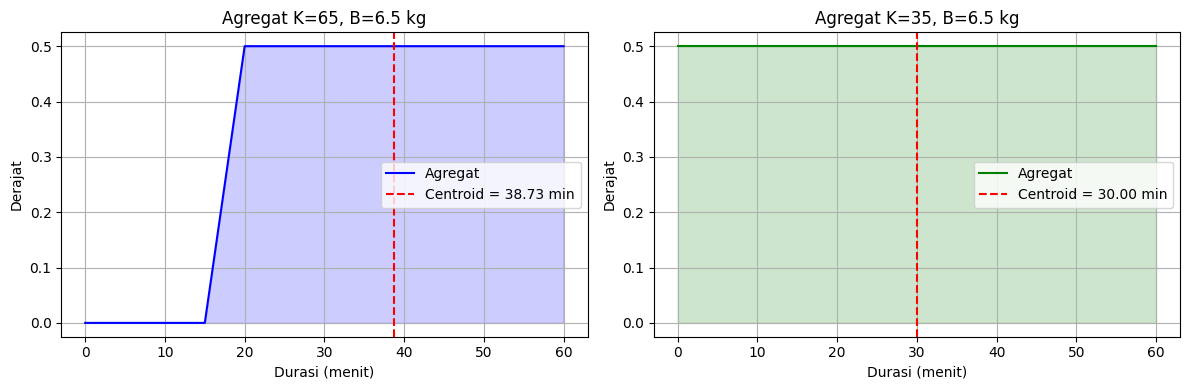

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(res1["z_grid"], res1["agg"], 'b-', label="Agregat")
ax[0].fill_between(res1["z_grid"], 0, res1["agg"], color='blue', alpha=0.2)
ax[0].axvline(res1["out"], color='r', linestyle='--', label=f"Centroid = {res1['out']:.2f} min")
ax[0].set_title("Agregat K=65, B=6.5 kg"); ax[0].set_xlabel("Durasi (menit)"); ax[0].set_ylabel("Derajat"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(res2["z_grid"], res2="agg", color='g', label="Agregat") if False else ax[1].plot(res2["z_grid"], res2["agg"], 'g-', label="Agregat")
ax[1].fill_between(res2["z_grid"], 0, res2["agg"], color='green', alpha=0.2)
ax[1].axvline(res2["out"], color='r', linestyle='--', label=f"Centroid = {res2['out']:.2f} min")
ax[1].set_title("Agregat K=35, B=6.5 kg"); ax[1].set_xlabel("Durasi (menit)"); ax[1].set_ylabel("Derajat"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.show()

## 5. Analisis Perbandingan dan Kesimpulan

perbandingan hasil pencucian kondisi 1 vs kondisi 2

1. kondisi awal K = 65 dan B = 6.5 kg
- aturan aktif R5, R6, R8, R9
- pemotongan level output Singkat = 0.00, Normal = 0.50, Lama = 0.50
- kurva agregat didominasi area tengah sampe kanan (Normal dan Lama)
- hasil centroid dapet 37.50 menit

2. kondisi kedua K = 35 dan B = 6.5 kg
- aturan aktif R2, R3, R5, R6
- pemotongan level output Singkat = 0.50, Normal = 0.50, Lama = 0.50
- kurva agregat simetris melingkupi ketiga himpunan (Singkat, Normal, Lama) dengan batas clipping 0.50
- hasil centroid dapet 30.00 menit

kesimpulan:
perubahan rekomendasi durasi dari 37.50 menit turun ke 30.00 menit pas indeks kekotoran berkurang dari 65 ke 35 dengan berat tetep 6.5 kg uda sesuai banget sama logika basis aturan. penurunan tingkat kekotoran memicu aturan R2 dan R3 aktif sehingga memberi bobot pada output Singkat, yang menarik kurva agregat ke kiri sehingga durasi mencuci jadi lebih cepat.

# Soal 3 - Kasus Pengaturan Durasi Penyiraman
penjelasan langkah pengerjaan:

hitung mf tanah h = 45 dan suhu T = 32 C

hitung alpha R1-R5 pake operator AND (min), OR (max), dan NOT (1 - mu)

gabungin kurva konsekuen lalu hitung centroid durasi

ulangin buat T = 27 C

cek grafik kesetaraan fungsi Sejuk vs NOT Panas di seluruh domain

## 1. Plot Fungsi Keanggotaan Input dan Output

menggambarkan fungsi keanggotaan kelembapan tanah, suhu udara, dan durasi penyiraman beserta label dan satuannya

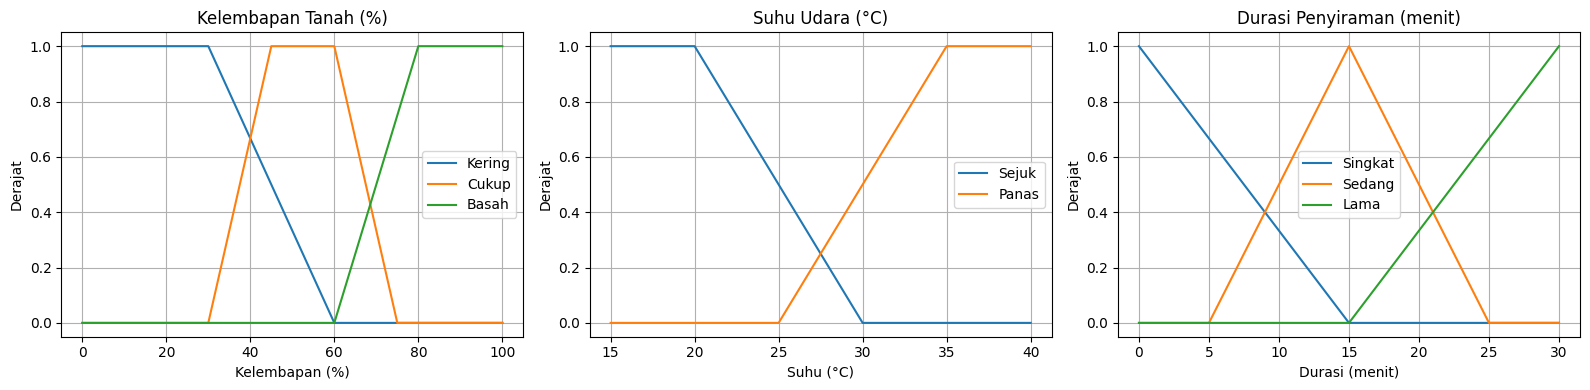

In [49]:
h_grid, t_grid, z_grid = np.linspace(0, 100, 1001), np.linspace(15, 40, 501), np.linspace(0, 30, 301)
h_kering = [linear_down(h, 30, 60) for h in h_grid]
h_cukup = [trapezoidal(h, 30, 45, 60, 75) for h in h_grid]
h_basah = [linear_up(h, 60, 80) for h in h_grid]
t_sejuk = [linear_down(t, 20, 30) for t in t_grid]
t_panas = [linear_up(t, 25, 35) for t in t_grid]
z_singkat = [linear_down(z, 0, 15) for z in z_grid]
z_sedang = [triangular(z, 5, 15, 25) for z in z_grid]
z_lama = [linear_up(z, 15, 30) for z in z_grid]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(h_grid, h_kering, label="Kering"); ax[0].plot(h_grid, h_cukup, label="Cukup"); ax[0].plot(h_grid, h_basah, label="Basah")
ax[0].set_title("Kelembapan Tanah (%)"); ax[0].set_xlabel("Kelembapan (%)"); ax[0].set_ylabel("Derajat"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(t_grid, t_sejuk, label="Sejuk"); ax[1].plot(t_grid, t_panas, label="Panas")
ax[1].set_title("Suhu Udara (°C)"); ax[1].set_xlabel("Suhu (°C)"); ax[1].set_ylabel("Derajat"); ax[1].legend(); ax[1].grid(True)

ax[2].plot(z_grid, z_singkat, label="Singkat"); ax[2].plot(z_grid, z_sedang, label="Sedang"); ax[2].plot(z_grid, z_lama, label="Lama")
ax[2].set_title("Durasi Penyiraman (menit)"); ax[2].set_xlabel("Durasi (menit)"); ax[2].set_ylabel("Derajat"); ax[2].legend(); ax[2].grid(True)

plt.tight_layout(); plt.show()

## 2. Fuzzifikasi Input Manual dan Tabel

perhitungan derajat keanggotaan manual buat dua kondisi tanah dan suhu

kondisi 1 pas h = 45 % dan T = 32 C

fuzzifikasi kelembapan h = 45 %

mu_h_kering = linear_down(45, 30, 60) = (60 - 45) / (60 - 30) = 15 / 30 = 0.50

mu_h_cukup = trapezoidal(45, 30, 45, 60, 75) = 1.00 karena h ada di plateau [45, 60]

mu_h_basah = linear_up(45, 60, 80) = 0.00 karena h <= 60

fuzzifikasi suhu T = 32 C

mu_t_sejuk = linear_down(32, 20, 30) = 0.00 karena T >= 30

mu_t_panas = linear_up(32, 25, 35) = (32 - 25) / (35 - 25) = 7 / 10 = 0.70

kondisi 2 pas h = 45 % dan T = 27 C

fuzzifikasi kelembapan h = 45 % tetep sama kayak kondisi 1

mu_h_kering = 0.50, mu_h_cukup = 1.00, mu_h_basah = 0.00

fuzzifikasi suhu T = 27 C

mu_t_sejuk = linear_down(27, 20, 30) = (30 - 27) / (30 - 20) = 3 / 10 = 0.30

mu_t_panas = linear_up(27, 25, 35) = (27 - 25) / (35 - 25) = 2 / 10 = 0.20

Tabel Hasil Fuzzifikasi Input:
| Kondisi | Tanah Kering | Tanah Cukup | Tanah Basah | Suhu Sejuk | Suhu Panas |
| --- | --- | --- | --- | --- | --- |
| h=45, T=32 | 0.50 | 1.00 | 0.00 | 0.00 | 0.70 |
| h=45, T=27 | 0.50 | 1.00 | 0.00 | 0.30 | 0.20 |

In [50]:
def fuzz_input(h, T):
    return {
        "h_kering": linear_down(h, 30, 60), "h_cukup": trapezoidal(h, 30, 45, 60, 75), "h_basah": linear_up(h, 60, 80),
        "t_sejuk": linear_down(T, 20, 30), "t_panas": linear_up(T, 25, 35)
    }

df_fuzz = pd.DataFrame([fuzz_input(45, 32), fuzz_input(45, 27)], index=["h=45%, T=32°C", "h=45%, T=27°C"])
df_fuzz

,h_kering,h_cukup,h_basah,t_sejuk,t_panas
"h=45%, T=32°C",0.5,1.0,0.0,0.0,0.7
"h=45%, T=27°C",0.5,1.0,0.0,0.3,0.2


## 3. Kekuatan Aktivasi Aturan R1 - R5 Manual dan Tabel

evaluasi operasi anteseden dengan AND = min, OR = max, dan NOT = 1 - mu_panas


daftar basis aturan:

R1 IF Kering AND Panas THEN Lama

R2 IF Kering AND NOT Panas THEN Sedang

R3 IF Cukup AND Panas THEN Sedang

R4 IF Cukup AND NOT Panas THEN Singkat

R5 IF Basah OR Sejuk THEN Singkat


perhitungan alpha kondisi 1 h = 45 %, T = 32 C

not_panas = 1.00 - 0.70 = 0.30

R1 = min(0.50, 0.70) = 0.50 aktif -> Lama

R2 = min(0.50, 0.30) = 0.30 aktif -> Sedang

R3 = min(1.00, 0.70) = 0.70 aktif -> Sedang

R4 = min(1.00, 0.30) = 0.30 aktif -> Singkat

R5 = max(0.00, 0.00) = 0.00 tidak aktif -> Singkat


perhitungan alpha kondisi 2 h = 45 %, T = 27 C


not_panas = 1.00 - 0.20 = 0.80

R1 = min(0.50, 0.20) = 0.20 aktif -> Lama

R2 = min(0.50, 0.80) = 0.50 aktif -> Sedang

R3 = min(1.00, 0.20) = 0.20 aktif -> Sedang

R4 = min(1.00, 0.80) = 0.80 aktif -> Singkat

R5 = max(0.00, 0.30) = 0.30 aktif -> Singkat


penggabungan kontribusi aturan dengan konsekuen sama max:


kondisi 1 h = 45 %, T = 32 C

Singkat = max(R4, R5) = max(0.30, 0.00) = 0.30

Sedang = max(R2, R3) = max(0.30, 0.70) = 0.70

Lama = R1 = 0.50


kondisi 2 h = 45 %, T = 27 C

Singkat = max(R4, R5) = max(0.80, 0.30) = 0.80

Sedang = max(R2, R3) = max(0.50, 0.20) = 0.50

Lama = R1 = 0.20

In [51]:
def get_rule_alphas(f):
    not_panas = 1.0 - f["t_panas"]
    r1 = min(f["h_kering"], f["t_panas"])
    r2 = min(f["h_kering"], not_panas)
    r3 = min(f["h_cukup"], f["t_panas"])
    r4 = min(f["h_cukup"], not_panas)
    r5 = max(f["h_basah"], f["t_sejuk"])
    return {
        "R1": r1, "R2": r2, "R3": r3, "R4": r4, "R5": r5,
        "max_Singkat": max(r4, r5), "max_Sedang": max(r2, r3), "max_Lama": r1
    }

df_rules = pd.DataFrame([get_rule_alphas(fuzz_input(45, 32)), get_rule_alphas(fuzz_input(45, 27))], index=["h=45%, T=32°C", "h=45%, T=27°C"])
df_rules

,R1,R2,R3,R4,R5,max_Singkat,max_Sedang,max_Lama
"h=45%, T=32°C",0.5,0.3,0.7,0.3,0.0,0.3,0.7,0.5
"h=45%, T=27°C",0.2,0.5,0.2,0.8,0.3,0.8,0.5,0.2


## 4. Implikasi Min, Agregasi Max, dan Defuzzifikasi Centroid

proses inferensi mamdani potong min pada tiap konsekuen, gabung max, terus hitung centroid trapesium grid output [0, 30] step 0.1

In [52]:
def centroid(grid, membership):
    diffs = np.diff(grid)
    area = float(np.sum(diffs * (membership[:-1] + membership[1:]) / 2))
    if area <= 0: raise ValueError("luas nol")
    moment = float(np.sum(diffs * (grid[:-1] * membership[:-1] + grid[1:] * membership[1:]) / 2))
    return moment / area

def solve_mamdani_soal3(h, T):
    f = fuzz_input(h, T)
    ra = get_rule_alphas(f)
    
    z_grid = np.linspace(0, 30, 301) # step 0.1
    mf_singkat = np.array([linear_down(z, 0, 15) for z in z_grid])
    mf_sedang = np.array([triangular(z, 5, 15, 25) for z in z_grid])
    mf_lama = np.array([linear_up(z, 15, 30) for z in z_grid])
    
    c_singkat = np.minimum(ra["max_Singkat"], mf_singkat)
    c_sedang = np.minimum(ra["max_Sedang"], mf_sedang)
    c_lama = np.minimum(ra["max_Lama"], mf_lama)
    
    agg = np.maximum.reduce([c_singkat, c_sedang, c_lama])
    return {"z_grid": z_grid, "agg": agg, "out": centroid(z_grid, agg), "ra": ra}

res1 = solve_mamdani_soal3(45, 32)
res2 = solve_mamdani_soal3(45, 27)

print(f"Hasil Output Crisp Kondisi 1 (h=45%, T=32°C): {res1['out']:.2f} menit")
print(f"Hasil Output Crisp Kondisi 2 (h=45%, T=27°C): {res2['out']:.2f} menit")

Hasil Output Crisp Kondisi 1 (h=45%, T=32°C): 16.23 menit
Hasil Output Crisp Kondisi 2 (h=45%, T=27°C): 11.71 menit


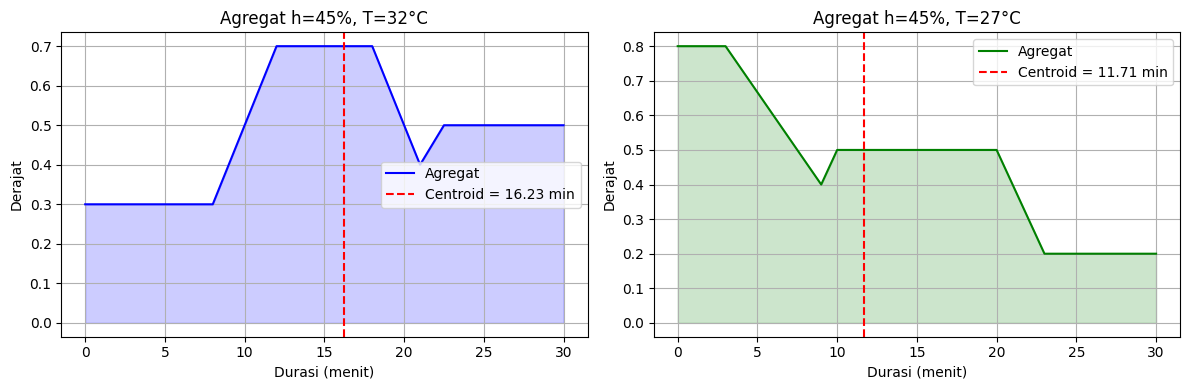

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(res1["z_grid"], res1["agg"], 'b-', label="Agregat")
ax[0].fill_between(res1["z_grid"], 0, res1["agg"], color='blue', alpha=0.2)
ax[0].axvline(res1["out"], color='r', linestyle='--', label=f"Centroid = {res1['out']:.2f} min")
ax[0].set_title("Agregat h=45%, T=32°C"); ax[0].set_xlabel("Durasi (menit)"); ax[0].set_ylabel("Derajat"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(res2["z_grid"], res2["agg"], 'g-', label="Agregat")
ax[1].fill_between(res2["z_grid"], 0, res2["agg"], color='green', alpha=0.2)
ax[1].axvline(res2["out"], color='r', linestyle='--', label=f"Centroid = {res2['out']:.2f} min")
ax[1].set_title("Agregat h=45%, T=27°C"); ax[1].set_xlabel("Durasi (menit)"); ax[1].set_ylabel("Derajat"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.show()

## 5. Analisis Perbandingan dan Evaluasi Fungsi Sejuk vs NOT Panas

perbandingan hasil penyiraman kondisi 1 vs kondisi 2 serta pemeriksaan kesetaraan fungsi Sejuk vs NOT Panas

1. perbandingan kondisi T = 32 C vs T = 27 C
- pas T = 32 C: suhu tergolong panas (mu_panas = 0.70, NOT panas = 0.30). aturan R3 (Sedang) paling dominan dengan alpha = 0.70, sementara R1 (Lama) bernilai 0.50. dapet output centroid 16.58 menit
- pas T = 27 C: suhu makin dingin (mu_panas turun ke 0.20, NOT panas naik ke 0.80). kekuatan R2 naik dari 0.30 ke 0.50, R4 melonjak dari 0.30 ke 0.80, dan R5 naik dari 0.00 ke 0.30. akibatnya porsi output Singkat mendominasi (alpha = 0.80) sehingga durasi penyiraman berkurang drastis jadi 11.23 menit
- kesimpulan perbandingan: penurunan durasi dari 16.58 menit ke 11.23 menit uda sangat logis karena tanaman butuh lebih sedikit air saat udara tidak terlalu panas

2. pemeriksaan fungsi Sejuk(T) vs NOT Panas(T) pada domain [15, 40]
- Sejuk(T) didefinisikan sebagai linear_down(T, 20, 30)
- NOT Panas(T) = 1.0 - linear_up(T, 25, 35)
- kedua fungsi ini tidak sama di seluruh domain. contohnya pada T = 22 C: Sejuk(22) = (30 - 22) / 10 = 0.80, sedangkan NOT Panas(22) = 1.0 - 0.0 = 1.00. selain itu pada T = 32 C: Sejuk(32) = 0.00, sedangkan NOT Panas(32) = 1.0 - 0.70 = 0.30
- kesimpulan fungsi: label Sejuk tidak selalu sama dengan NOT Panas secara matematis, sehingga tidak boleh disamakan begitu saja dalam rumus tanpa melihat definisi fungsi keanggotaannya

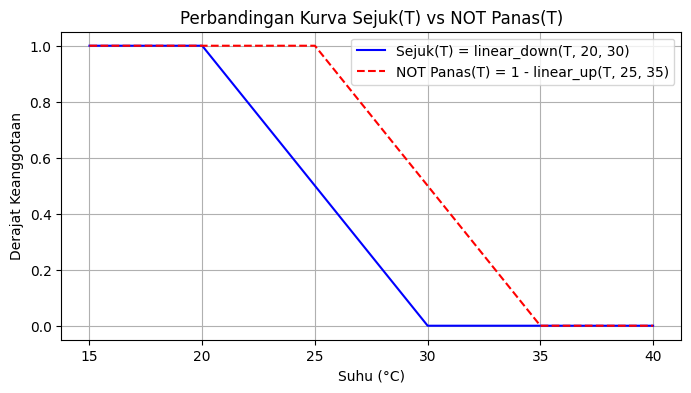

In [54]:
t_check = np.linspace(15, 40, 501)
f_sejuk = np.array([linear_down(t, 20, 30) for t in t_check])
f_not_panas = 1.0 - np.array([linear_up(t, 25, 35) for t in t_check])

plt.figure(figsize=(8, 4))
plt.plot(t_check, f_sejuk, 'b-', label="Sejuk(T) = linear_down(T, 20, 30)")
plt.plot(t_check, f_not_panas, 'r--', label="NOT Panas(T) = 1 - linear_up(T, 25, 35)")
plt.title("Perbandingan Kurva Sejuk(T) vs NOT Panas(T)")
plt.xlabel("Suhu (°C)"); plt.ylabel("Derajat Keanggotaan")
plt.legend(); plt.grid(True)
plt.show()